In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier


In [2]:
np.random.seed(42)

# Normal transactions
X_normal = np.random.normal(loc=0, scale=1, size=(300, 2))
y_normal = np.zeros(300)

# Fraudulent transactions (dense region / bump)
X_fraud = np.random.normal(loc=3, scale=0.4, size=(100, 2))
y_fraud = np.ones(100)

# Combine data
X = np.vstack((X_normal, X_fraud))
y = np.hstack((y_normal, y_fraud))

df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df["Fraud"] = y


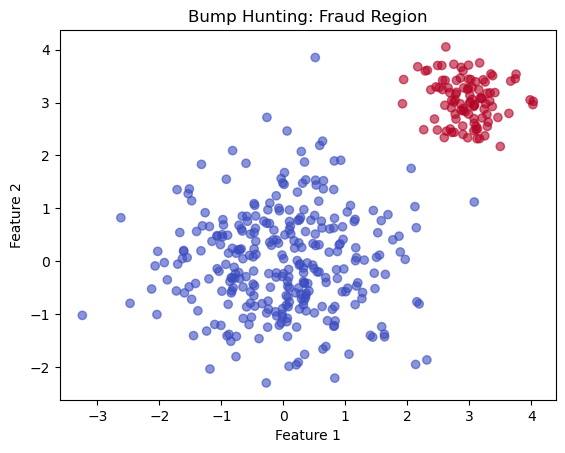

In [3]:
plt.scatter(df["Feature_1"], df["Feature_2"],
        c=df["Fraud"], cmap="coolwarm", alpha=0.6)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Bump Hunting: Fraud Region")
plt.show()


In [5]:
tree = DecisionTreeClassifier(
max_depth=3,
min_samples_leaf=20,
random_state=42
)
tree.fit(df[["Feature_1", "Feature_2"]], df["Fraud"])


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
df["Fraud_Probability"] = tree.predict_proba(
df[["Feature_1", "Feature_2"]]
)[:, 1]

bumps = df[df["Fraud_Probability"] > 0.8]
bumps.head()


,Feature_1,Feature_2,Fraud,Fraud_Probability
56,0.060230,2.463242,0.0,0.85
89,-0.264657,2.720169,0.0,0.85
104,0.515048,3.852731,0.0,0.85
300,3.302795,2.631134,1.0,1.00
301,3.347842,3.542255,1.0,1.00
